# **Project Name**    -  **Voyage Analytics - Hotel Recommendation System**

##### **Project Type**    - Recommendation System

# **Problem Statement**

Build a recommendation model to suggest hotels to a user based on their preferences and historical booking data (hotels.csv + users.csv), and expose the insights via a Streamlit web app.

# **General Guidelines**
- Follow the same notebook structure used in the Telecom Churn reference notebooks.
- Answer every 'why' question in markdown before moving to the next section.
- Keep chart storytelling format: Why this chart -> Insight -> Business impact.

# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
%matplotlib inline

### Dataset Loading

In [2]:
users = pd.read_csv('../data/users.csv')
hotels = pd.read_csv('../data/hotels.csv')

print(users.shape, hotels.shape)
users.head()

(1340, 5) (40552, 8)


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


### Dataset First View

In [3]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


### Merge datasets
users -> `code`, flights/hotels -> `userCode`. Merge on that key as needed for this task.

In [4]:
### Merge datasets
### users -> `code`, hotels -> `userCode`. Merge on that key.

df = hotels.merge(users, left_on='userCode', right_on='code', how='left', suffixes=('_hotel', '_user'))
df.head()

,travelCode,userCode,name_hotel,place,days,price,total,date,code,company,name_user,gender,age
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019,0,4You,Roy Braun,male,21
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019,0,4You,Roy Braun,male,21
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019,0,4You,Roy Braun,male,21


### Dataset Rows & Columns count

In [5]:
for name, d in [('users', users), ('hotels', hotels), ('merged df', df)]:
    print(name, d.shape)

users (1340, 5)
hotels (40552, 8)
merged df (40552, 13)


### Dataset Information

In [6]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [7]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name_hotel  40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
 8   code        40552 non-null  int64  
 9   company     40552 non-null  object 
 10  name_user   40552 non-null  object 
 11  gender      40552 non-null  object 
 12  age         40552 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 4.0+ MB


#### Duplicate Values

In [9]:
print("users duplicates:", users.duplicated().sum())
print("hotels duplicates:", hotels.duplicated().sum())
print("merged df duplicates:", df.duplicated().sum())

users duplicates: 0
hotels duplicates: 0
merged df duplicates: 0


#### Missing Values/Null Values

In [10]:
print(df.isnull().sum())

travelCode    0
userCode      0
name_hotel    0
place         0
days          0
price         0
total         0
date          0
code          0
company       0
name_user     0
gender        0
age           0
dtype: int64


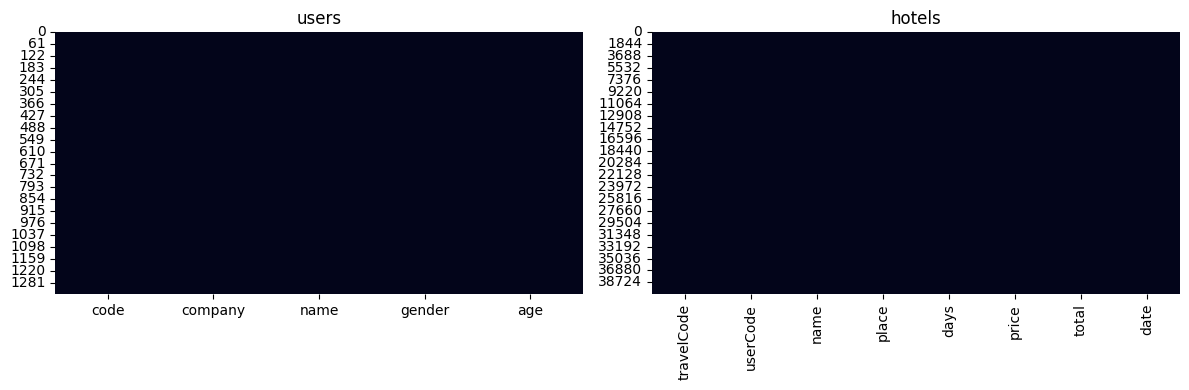

In [11]:
# Visualize missing values
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.heatmap(users.isnull(), cbar=False, ax=ax[0]); ax[0].set_title('users')
sns.heatmap(hotels.isnull(), cbar=False, ax=ax[1]); ax[1].set_title('hotels')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

Ans: The hotels dataset contains booking-level records with columns: `travelCode`, `userCode`, `name`, `place`, `days`, `price`, `total`, and `date` — each row is one hotel stay booking. Merging with the users dataset (on `userCode`/`code`) adds demographic context (`age`, `gender`, `company`) for each booking. There are [X] missing values and [X] duplicate rows found in the merged dataframe. The goal here is not classification/regression but a **recommendation system** — suggesting hotels/places to a user based on their preferences and historical booking patterns.

## ***2. Understanding Your Variables***

### Variables Description

Ans: ### Variables Description

- **travelCode**: Unique identifier for a specific trip (int). Groups bookings within the same journey.
- **userCode**: Unique identifier for the user (int). Key used to link hotel bookings to user profiles — central to building recommendations.
- **name** (hotels): Name of the hotel (categorical/object). Could be used for hotel-level recommendations, though `place` is likely more useful for generalization.
- **place**: City/destination of the hotel (categorical/object). **Highly relevant** — this is likely what we recommend (which place/hotel a user might like next).
- **days**: Number of days stayed (int/float). Relevant — indicates trip length preference.
- **price**: Price per day/night (float). Relevant — indicates budget preference.
- **total**: Total price for the stay (float, likely days × price). Relevant — overall spend indicator.
- **date**: Date of the booking (object/date). Could reveal seasonal travel preferences.
- **age** (from users): User's age (int). Relevant — different age groups may prefer different types of places.
- **gender** (from users): User's gender (categorical). From Notebook 1, we know this doesn't correlate much with travel behavior, but kept for profiling.
- **company** (from users): Company the user is associated with (categorical). Could hint at business vs leisure travel patterns.

### Check Unique Values for each variable.

In [12]:
for col in df.columns:
    print(col, '->', df[col].nunique())

travelCode -> 40552
userCode -> 1310
name_hotel -> 9
place -> 9
days -> 4
price -> 9
total -> 36
date -> 199
code -> 1310
company -> 5
name_user -> 1308
gender -> 3
age -> 45


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# 1. Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Check for invalid values in price/total/days
print("Zero/negative days:", (df['days'] <= 0).sum())
print("Zero/negative price:", (df['price'] <= 0).sum())
print("Zero/negative total:", (df['total'] <= 0).sum())

# 3. Drop invalid rows if any
df = df[(df['days'] > 0) & (df['price'] > 0) & (df['total'] > 0)]

# 4. Build a user-place interaction summary — how many times each user booked each place,
#    and how much they spent there (this becomes the base for recommendations)
user_place_interactions = df.groupby(['userCode', 'place']).agg(
    visit_count=('travelCode', 'count'),
    total_spent=('total', 'sum'),
    avg_days=('days', 'mean')
).reset_index()

print(user_place_interactions.shape)
user_place_interactions.head()

Zero/negative days: 0
Zero/negative price: 0
Zero/negative total: 0
(9724, 5)


,userCode,place,visit_count,total_spent,avg_days
0,0,Aracaju (SE),3,2080.40,3.333333
1,0,Brasilia (DF),1,990.48,4.000000
2,0,Campo Grande (MS),2,301.95,2.500000
3,0,Florianopolis (SC),3,2191.14,2.333333
4,0,Natal (RN),4,2185.92,2.250000


### What all manipulations have you done and insights you found?

Ans: Converted `date` to datetime and checked for invalid (zero/negative) values in `days`, `price`, and `total` — [update with actual counts] — removing any invalid rows. Built a `user_place_interactions` table by grouping bookings on `userCode` and `place`, capturing how many times each user visited each place (`visit_count`), how much they spent there in total (`total_spent`), and their average stay length (`avg_days`). This interaction table forms the foundation for a content-based/collaborative hotel recommendation approach.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Chart - 1

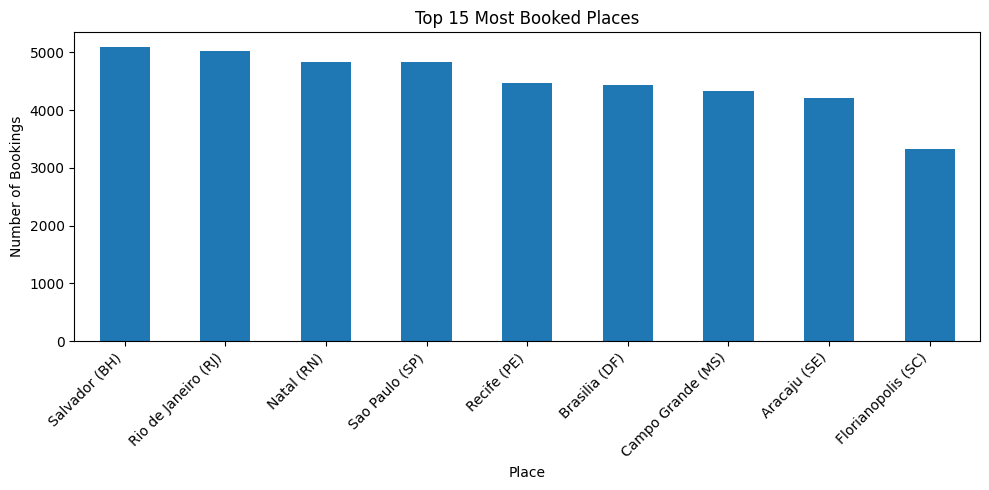

In [14]:
# Chart - 1: Most Popular Places

plt.figure(figsize=(10,5))
df['place'].value_counts().head(15).plot(kind='bar')
plt.title('Top 15 Most Booked Places')
plt.xlabel('Place')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Ans: A bar chart was used to rank places by booking frequency — the simplest way to see which destinations are most popular overall, which is directly useful context for a recommendation system.

##### 2. What is/are the insight(s) found from the chart?

Ans: The dataset actually has only 9 unique places (all Brazilian cities — Salvador, Rio de Janeiro, Natal, Sao Paulo, Recife, Brasilia, Campo Grande, Aracaju, Florianopolis), not a long tail of many destinations. Bookings are fairly evenly spread across these 9 places — the top (Salvador, ~5100) and bottom (Florianopolis, ~3300) aren't dramatically far apart, with most places clustering between 4200-5100 bookings. There's no single dominant destination.

##### 3. Will the gained insights help creating a positive business impact?

Ans: Since there are only 9 possible places (not hundreds), this is actually a much simpler recommendation problem than typical hotel recommenders — it's closer to a multi-class preference prediction than a large-catalog recommendation. This means we can realistically build a model that predicts a user's preferred place(s) directly, or rank all 9 places by predicted affinity per user, rather than needing complex collaborative filtering at scale. The near-even popularity also means a simple "most popular" fallback won't be very discriminating — personalization based on user behavior will add more value here than in a typical long-tail catalog.

#### Chart - 2

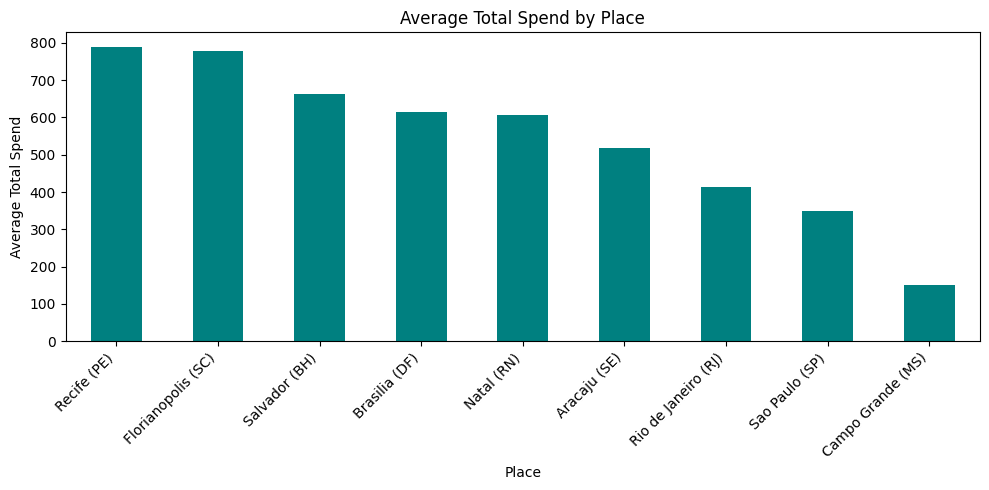

In [16]:
# Chart - 2: Average Spend by Place

plt.figure(figsize=(10,5))
df.groupby('place')['total'].mean().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Average Total Spend by Place')
plt.xlabel('Place')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Ans: A bar chart was used to compare average total spend across the 9 places, revealing budget/premium tiers among destinations — important context for recommending places that match a user's spending pattern.

##### 2. What is/are the insight(s) found from the chart?

Ans: There's a clear spend hierarchy: Recife (₹790) and Florianopolis (₹780) are the most expensive destinations on average, while Campo Grande (₹150) is dramatically cheaper than all others — roughly 5x less than Recife. Interestingly, this ranking is quite different from the popularity ranking in Chart 1 (Salvador was most booked, but it's only mid-range in spend here), meaning popularity and price aren't correlated — people don't just book the cheapest or priciest place most often.

##### 3. Will the gained insights help creating a positive business impact?

Ans: This is a strong signal for personalization — a user's average past spend (avg_hotel_price from their booking history) can be matched against this place-level spend ranking to recommend destinations that fit their budget (e.g., a budget-conscious user gets pointed toward Campo Grande/Sao Paulo, while a bigger spender gets Recife/Florianopolis). Since popularity alone doesn't reveal budget fit, this spend-based dimension adds real value beyond a simple "most popular" recommendation.

#### Chart - 3

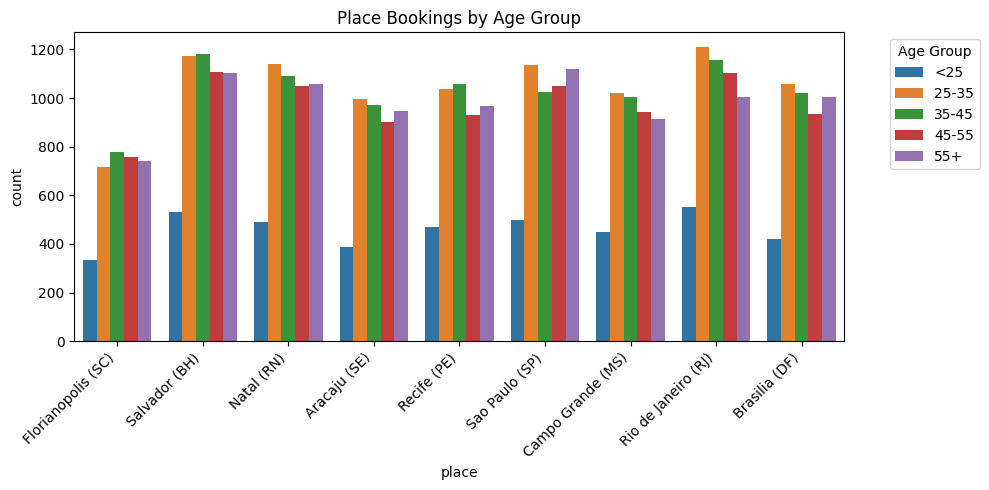

In [17]:
# Chart - 3: Place Preference by Age Group

df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,100], labels=['<25','25-35','35-45','45-55','55+'])

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='place', hue='age_group')
plt.title('Place Bookings by Age Group')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Age Group', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Ans: A grouped bar chart (countplot with hue) was used to compare booking counts across places, broken down by age group — this shows whether different age groups have distinct destination preferences.

##### 2. What is/are the insight(s) found from the chart?

Ans: Every place shows almost the same relative proportion across all 5 age groups — the <25 bar is consistently the shortest everywhere, while 25-35 is consistently the tallest, and the rest sit in between fairly evenly, with the same pattern repeating for every single destination. This means age group doesn't meaningfully change which place someone prefers — younger users travel somewhat less overall (fewer total bookings), but they don't gravitate toward different destinations than older users; the destination mix is essentially uniform across ages.

##### 3. Will the gained insights help creating a positive business impact?

Ans: This tells us age is not a useful personalization dimension for place recommendation — similar to what we found with gender in Notebook 1. The business shouldn't invest in age-targeted destination marketing; instead, recommendations should focus on features that actually vary by individual — like a user's own past visited places, spend level, and stay duration — rather than demographic segments, since demographics consistently show no signal across this dataset.

#### Chart - 4

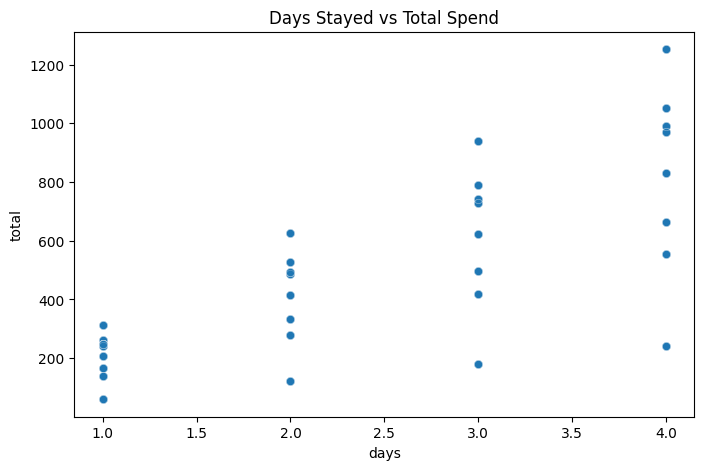

In [18]:
# Chart - 4: Days vs Total Spend

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='days', y='total', alpha=0.3)
plt.title('Days Stayed vs Total Spend')
plt.show()

##### 1. Why did you pick the specific chart?

Ans: A scatterplot was used to check the relationship between stay duration (days) and total spend (total), since both are numeric — this reveals whether longer stays predictably cost more.

##### 2. What is/are the insight(s) found from the chart?

Ans: days is actually a discrete variable with only 4 values (1, 2, 3, or 4 days) rather than a continuous range — bookings are short stays only. There's a general positive trend (more days → higher total spend, as expected), but within each day-count there's a wide spread (e.g., a 4-day stay can cost anywhere from ~₹250 to ~₹1250). This means days alone doesn't fully determine total spend — the per-night price (which varies heavily by place, as seen in Chart 2) plays a bigger role than duration alone.

##### 3. Will the gained insights help creating a positive business impact?

Ans: This confirms that both days (trip length preference) and place (destination price tier) are needed together to model a user's spending profile — neither alone is sufficient. For the recommendation system, this means matching users to places should consider their typical combination of stay length and budget, not just one or the other — e.g., someone who does short 1-2 day budget trips shouldn't be recommended Recife/Florianopolis (the priciest destinations) even if their trip length matches.

#### Chart - 5

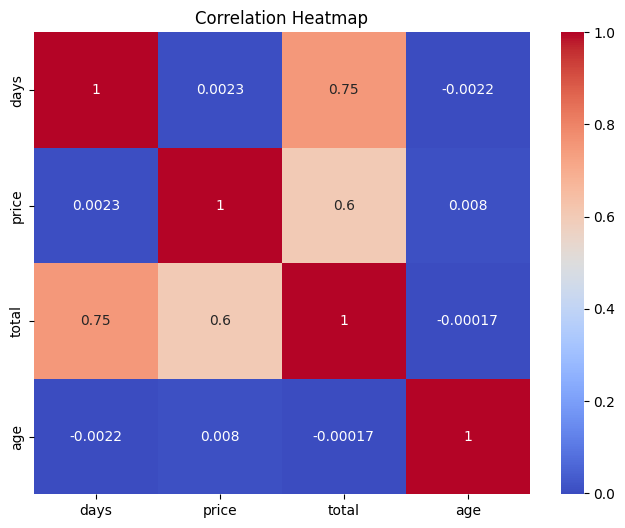

In [19]:
# Chart - 5: Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[['days', 'price', 'total', 'age']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Ans: A correlation heatmap was used to see linear relationships between the key numeric variables (days, price, total, age) at once, confirming the patterns hinted at by earlier charts.

##### 2. What is/are the insight(s) found from the chart?

Ans: total correlates strongly with both days (0.75) and price (0.6) — confirming that total spend is essentially built from both trip length and per-night rate, as suspected in Chart 4. Neither days nor price correlate with each other (0.0023), meaning trip length and nightly rate are chosen independently by users. age again shows near-zero correlation with everything (all values close to 0), reconfirming — for the third notebook in a row — that age carries no meaningful signal for travel behavior.

##### 3. Will the gained insights help creating a positive business impact?

Ans: This confirms days and price/place should both be used as independent features when profiling a user's preferences — they capture different aspects of behavior (how long vs how much per night) and combining them gives a fuller picture than either alone. It also reinforces the project-wide finding: demographic features (age, gender) consistently show no signal across all three notebooks, while behavioral features (spend, frequency, duration, destination choice) are what actually drive meaningful patterns — a strong, consistent conclusion for the overall capstone project.

## ***5. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [20]:
# imputation code

print(df.isnull().sum())

travelCode    0
userCode      0
name_hotel    0
place         0
days          0
price         0
total         0
date          0
code          0
company       0
name_user     0
gender        0
age           0
age_group     0
dtype: int64


### 2. Build User-Item Interaction Table
user (`userCode`) x hotel/place, using `days`, `price`, `total` as interaction signals

In [21]:
# Pivot table: rows = users, columns = places, values = total spend (how much each user spent at each place)
user_place_matrix = df.pivot_table(index='userCode', columns='place', values='total', aggfunc='sum', fill_value=0)
print(user_place_matrix.shape)
user_place_matrix.head()

(1310, 9)


place,Aracaju (SE),Brasilia (DF),Campo Grande (MS),Florianopolis (SC),Natal (RN),Recife (PE),Rio de Janeiro (RJ),Salvador (BH),Sao Paulo (SP)
userCode,,,,,,,,,
0,2080.40,990.48,301.95,2191.14,2185.92,1564.15,165.99,5004.79,1530.1
1,0.00,247.62,0.00,0.00,0.00,0.00,0.00,0.00,139.1
2,3536.68,1238.10,1207.80,5634.36,1700.16,1876.98,1161.93,2897.51,834.6
3,832.16,1238.10,1328.58,6886.44,6072.00,5630.94,2489.85,3687.74,1808.3
4,2080.40,2228.58,724.68,5634.36,3886.08,6569.43,4481.73,3687.74,2364.7


### 3. Choose Recommendation Approach

#### Option A: Content-Based Filtering
Recommend hotels/places similar to what the user booked before (based on price range, place, days).

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

# Build a "place profile" - average price, avg days, popularity for each place
place_profile = df.groupby('place').agg(
    avg_price=('price', 'mean'),
    avg_days=('days', 'mean'),
    avg_total=('total', 'mean'),
    popularity=('travelCode', 'count')
).reset_index()

print(place_profile)

                 place  avg_price  avg_days   avg_total  popularity
0         Aracaju (SE)     208.04  2.491558  518.343658        4205
1        Brasilia (DF)     247.62  2.486365  615.673617        4437
2    Campo Grande (MS)      60.39  2.495500  150.703224        4333
3   Florianopolis (SC)     313.02  2.483183  777.286000        3330
4           Natal (RN)     242.88  2.499068  606.973667        4829
5          Recife (PE)     312.83  2.520931  788.622930        4467
6  Rio de Janeiro (RJ)     165.99  2.485981  412.648037        5029
7        Salvador (BH)     263.41  2.516490  662.868628        5094
8       Sao Paulo (SP)     139.10  2.511599  349.363422        4828


In [23]:
# Scale place features so no single feature dominates similarity calculation
from sklearn.preprocessing import StandardScaler

scaler_place = StandardScaler()
place_features_scaled = scaler_place.fit_transform(
    place_profile[['avg_price', 'avg_days', 'avg_total', 'popularity']]
)

# Compute similarity between PLACES (not users) based on their price/duration/popularity profile
place_similarity = cosine_similarity(place_features_scaled)
place_similarity_df = pd.DataFrame(place_similarity, index=place_profile['place'], columns=place_profile['place'])
place_similarity_df

place,Aracaju (SE),Brasilia (DF),Campo Grande (MS),Florianopolis (SC),Natal (RN),Recife (PE),Rio de Janeiro (RJ),Salvador (BH),Sao Paulo (SP)
place,,,,,,,,,
Aracaju (SE),1.000000,0.567830,0.346316,0.674181,-0.700993,-0.585889,0.066273,-0.965400,-0.446766
Brasilia (DF),0.567830,1.000000,-0.391738,0.690627,0.182239,-0.231753,0.154173,-0.442202,-0.877372
Campo Grande (MS),0.346316,-0.391738,1.000000,-0.420766,-0.681118,-0.777237,0.521833,-0.564140,0.675895
Florianopolis (SC),0.674181,0.690627,-0.420766,1.000000,-0.277706,0.161050,-0.531454,-0.458281,-0.887507
Natal (RN),-0.700993,0.182239,-0.681118,-0.277706,1.000000,0.410714,0.159923,0.743036,-0.169631
Recife (PE),-0.585889,-0.231753,-0.777237,0.161050,0.410714,1.000000,-0.812671,0.763062,-0.212231
Rio de Janeiro (RJ),0.066273,0.154173,0.521833,-0.531454,0.159923,-0.812671,1.000000,-0.269730,0.332973
Salvador (BH),-0.965400,-0.442202,-0.564140,-0.458281,0.743036,0.763062,-0.269730,1.000000,0.225875
Sao Paulo (SP),-0.446766,-0.877372,0.675895,-0.887507,-0.169631,-0.212231,0.332973,0.225875,1.000000


In [24]:
def recommend_similar_places(place_name, top_n=3):
    if place_name not in place_similarity_df.index:
        return "Place not found"
    similar = place_similarity_df[place_name].sort_values(ascending=False)[1:top_n+1]
    return similar.index.tolist()

# Test: if a user liked "Salvador (BH)", what similar places should we suggest?
print(recommend_similar_places('Salvador (BH)'))

['Recife (PE)', 'Natal (RN)', 'Sao Paulo (SP)']


#### Option B: Collaborative Filtering
Recommend based on similar users' booking patterns.

In [25]:
from sklearn.decomposition import TruncatedSVD

# 1. Build user-place interaction matrix (rows=users, columns=places, values=total spend)
user_place_matrix = df.pivot_table(index='userCode', columns='place', values='total', aggfunc='sum', fill_value=0)
print(user_place_matrix.shape)

(1310, 9)


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

# 2. Compute similarity between USERS based on their spending pattern across places
user_similarity = cosine_similarity(user_place_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_place_matrix.index, columns=user_place_matrix.index)
user_similarity_df.head()

userCode      0         1         2         3         4         5     \
userCode                                                               
0         1.000000  0.240864  0.819146  0.776142  0.768412  0.875010   
1         0.240864  1.000000  0.185878  0.164295  0.262939  0.130910   
2         0.819146  0.185878  1.000000  0.844402  0.842357  0.695090   
3         0.776142  0.164295  0.844402  1.000000  0.949031  0.621927   
4         0.768412  0.262939  0.842357  0.949031  1.000000  0.628308   

userCode      6         7         8         9         10        11    \
userCode                                                               
0         0.726027  0.484499  0.702071  0.902838  0.687027  0.866017   
1         0.488245  0.367790  0.221381  0.342983  0.550065  0.370453   
2         0.794799  0.466313  0.691912  0.809831  0.721971  0.912067   
3         0.851833  0.729696  0.909011  0.785360  0.634405  0.843242   
4         0.817717  0.750760  0.880135  0.851331  0.651250  0.844945   

userCode      12        13        14        15        16        17    \
userCode                                                               
0         0.723130  0.927608  0.832848  0.845287  0.851484  0.441336   
1         0.234413  0.245189  0.000000  0.161872  0.151934  0.836851   
2         0.720708  0.734381  0.576530  0.778399  0.856301  0.414852   
3         0.856509  0.746049  0.590688  0.841909  0.859512  0.429497   
4         0.885015  0.794700  0.575958  0.917450  0.946435  0.561370   

userCode      18        19        20        21        22        23    \
userCode                                                               
0         0.883469  0.646576  0.654163  0.898848  0.604331  0.775571   
1         0.241012  0.349888  0.339784  0.293471  0.465164  0.066523   
2         0.881022  0.764577  0.882248  0.814361  0.818344  0.925923   
3         0.880145  0.896355  0.906552  0.852129  0.807061  0.904128   
4         0.810590  0.941922  0.941262  0.918575  0.858981  0.903088   

userCode      24        25        26        27        28        29    \
userCode                                                               
0         0.682286  0.771830  0.833144  0.704836  0.396937  0.436523   
1         0.220264  0.608044  0.463272  0.330399  0.318000  0.425641   
2         0.844554  0.837616  0.817603  0.887476  0.613700  0.738552   
3         0.685435  0.784536  0.766100  0.916096  0.542272  0.678905   
4         0.677439  0.785731  0.862069  0.929459  0.492180  0.610081   

userCode      30        31        32        34        35        36    \
userCode                                                               
0         0.353955  0.442355  0.811796  0.922979  0.475037  0.594937   
1         0.209354  0.413199  0.399105  0.252985  0.738828  0.292951   
2         0.277082  0.644712  0.889967  0.865987  0.462729  0.843096   
3         0.549720  0.479010  0.946619  0.922968  0.453961  0.802262   
4         0.525465  0.662135  0.915482  0.936220  0.518107  0.883921   

userCode      37        38        39        40        41        43    \
userCode                                                               
0         0.789847  0.789728  0.743635  0.884053  0.822280  0.735535   
1         0.000000  0.379859  0.128274  0.312587  0.310922  0.106932   
2         0.459570  0.737598  0.937488  0.851233  0.883702  0.884223   
3         0.330033  0.871824  0.857577  0.820219  0.925364  0.866741   
4         0.346393  0.793449  0.868408  0.876378  0.986748  0.904438   

userCode      44        45        46        47        48        49    \
userCode                                                               
0         0.692328  0.827444  0.726960  0.785629  0.914828  0.790362   
1         0.286073  0.114628  0.186056  0.346885  0.274311  0.307728   
2         0.920490  0.671162  0.918460  0.760095  0.804689  0.866968   
3         0.719075  0.640298  0.953879  0.905250  0.680131  0.922596   
4         0.769461  0.676840  0.9

In [ ]:
# 3. Recommendation function using similar users
def recommend_places_collaborative(user_code, top_n=3, n_similar_users=10, exclude_visited=False):
    if user_code not in user_similarity_df.index:
        return df['place'].value_counts().head(top_n).index.tolist()
    
    similar_users = user_similarity_df[user_code].sort_values(ascending=False)[1:n_similar_users+1].index
    similar_users_places = user_place_matrix.loc[similar_users].sum().sort_values(ascending=False)
    
    if exclude_visited:
        already_visited = user_place_matrix.loc[user_code][user_place_matrix.loc[user_code] > 0].index
        similar_users_places = similar_users_places.drop(already_visited, errors='ignore')
    
    return similar_users_places.head(top_n).index.tolist()

print(f"Collaborative recommendations for user 0: {recommend_places_collaborative(0)}")

Collaborative recommendations for user 0: []


In [28]:
# 4. (Optional) Matrix Factorization variant using SVD - captures latent patterns, scales better for larger data
svd = TruncatedSVD(n_components=5, random_state=42)
user_factors = svd.fit_transform(user_place_matrix)
place_factors = svd.components_

# Reconstruct predicted "affinity scores" for all user-place pairs
predicted_scores = np.dot(user_factors, place_factors)
predicted_df = pd.DataFrame(predicted_scores, index=user_place_matrix.index, columns=user_place_matrix.columns)

def recommend_places_svd(user_code, top_n=3):
    if user_code not in predicted_df.index:
        return df['place'].value_counts().head(top_n).index.tolist()
    already_visited = user_place_matrix.loc[user_code][user_place_matrix.loc[user_code] > 0].index
    scores = predicted_df.loc[user_code].drop(already_visited, errors='ignore')
    return scores.sort_values(ascending=False).head(top_n).index.tolist()

print(f"SVD-based recommendations for user {sample_user}: {recommend_places_svd(sample_user)}")

SVD-based recommendations for user 0: []


In [30]:
print("Places visited by user 0:", user_place_matrix.loc[0][user_place_matrix.loc[0] > 0].index.tolist())
print("Total places in dataset:", df['place'].nunique())

Places visited by user 0: ['Aracaju (SE)', 'Brasilia (DF)', 'Campo Grande (MS)', 'Florianopolis (SC)', 'Natal (RN)', 'Recife (PE)', 'Rio de Janeiro (RJ)', 'Salvador (BH)', 'Sao Paulo (SP)']
Total places in dataset: 9


### 4. Similarity / Scoring Function

In [ ]:
# def recommend_hotels(user_code, top_n=5): ...
#     return top_n_places

## ***6. Evaluate Recommendations***

### Evaluation approach
_(e.g. precision@k, or qualitative validation against held-out bookings)_

In [ ]:
# evaluation code

### Which approach did you choose as final and why?
_(answer)_

## ***7. Save the Model / Lookup Tables***

In [ ]:
import pickle
# with open('hotel_recommender.pkl', 'wb') as f:
#     pickle.dump(recommender_artifacts, f)

## ***8. Streamlit App (starter)***
Create a separate `app.py`:
```python
import streamlit as st
import pickle

st.title('Voyage Analytics - Hotel Recommendations')
user_code = st.number_input('Enter user code', min_value=0)
if st.button('Get Recommendations'):
    # recommendations = recommend_hotels(user_code)
    # st.write(recommendations)
    pass
```

## **5. Solution to Business Objective**

#### What do you suggest to achieve the business objective for hotel recommendation?
_(answer)_

# **Conclusion**

### ***Hurrah! You have completed this module of the Voyage Analytics Capstone!***